In [22]:
# importing required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [23]:
# now we are extracting text from Alice's Adevntures in Wonderland
# we will be working on this
# fetch data using API and request
import requests

def extract_info_web(url):
  data = None
  try:
    response = requests.get(url)
    if response.status_code != 200:
      print("Error Occurred while fetching the data from web.")
      return None

    data = response.text
  except Exception as e:
    print(e)

  return data

In [24]:
alice_data = extract_info_web("https://gutenberg.org/cache/epub/11/pg11.txt")
print(alice_data[:300])

The Project Gutenberg eBook of Alice's Adventures in Wonderland
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Proje


In [25]:
# now we have the data
# next step is to clean the text
# main book text content is in between start_str and end_str which is
start_str = "*** START OF THE PROJECT GUTENBERG EBOOK ALICE'S ADVENTURES IN WONDERLAND ***"
end_str = "*** END OF THE PROJECT GUTENBERG EBOOK ALICE'S ADVENTURES IN WONDERLAND ***"
start,end = None,None
list1 = [item.strip() for item in alice_data.split("\n")]

for i in range(len(list1)):
  if list1[i] == start_str:
    start = i

  elif list1[i] == end_str:
    end = i

if start is None or end is None:
    print("Warning: start or end marker not found — check exact marker text.")
else:
    main_text = '\n'.join(list1[start+1:end])
    print("First 300 chars:\n", main_text[:300])
    print("\nLast 300 chars:\n", main_text[-300:])

First 300 chars:
 
[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

CHAPTER I.     Down the Rabbit-Hole
CHAPTER II.    The Pool of Tears
CHAPTER III.   A Caucus-Race and a Long Tale
CHAPTER IV.    The Rabbit Sends in a Little Bill
CHAPTER V.     Advi

Last 300 chars:
 children,
and make _their_ eyes bright and eager with many a strange tale,
perhaps even with the dream of Wonderland of long ago: and how she
would feel with all their simple sorrows, and find a pleasure in all
their simple joys, remembering her own child-life, and the happy summer
days.

THE END





In [26]:
# now preprocessing step
# lowercase
# removing unnecessary elements

def preprocess(text):
  text = text.lower()
  text = re.findall(r"[a-z]+(?:['’][a-z]+)?",text)
  return text

In [27]:
tokens = preprocess(main_text)
print(f"length of tokens: {len(tokens)}")

length of tokens: 26776


In [28]:
# for sanity check
print(tokens[:20])

['illustration', 'alice’s', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', 'contents', 'chapter', 'i', 'down', 'the', 'rabbit', 'hole', 'chapter']


In [29]:
# now using Counter from collections to count the words
# how many times it appeared
from collections import Counter

token_dict = Counter(tokens)
print(token_dict.most_common(10))

[('the', 1651), ('and', 874), ('to', 729), ('a', 637), ('she', 541), ('it', 530), ('of', 515), ('said', 462), ('i', 411), ('alice', 386)]


In [30]:
# now will be using log-log scale to check zipf's law
# will create two numpy arrays
freq = [num for word,num in token_dict.most_common()]
ranks = np.array(range(1,len(freq)+1))

# now converting them into log scale
log_freq = [np.log(num) for num in freq]
log_ranks = [np.log(rank) for rank in ranks]

In [31]:
# for sanity check
print(log_freq[:5])

[np.float64(7.409136443920128), np.float64(6.773080375655535), np.float64(6.591673732008658), np.float64(6.456769655572163), np.float64(6.293419278846481)]


In [32]:
print(log_ranks[:5])

[np.float64(0.0), np.float64(0.6931471805599453), np.float64(1.0986122886681098), np.float64(1.3862943611198906), np.float64(1.6094379124341003)]


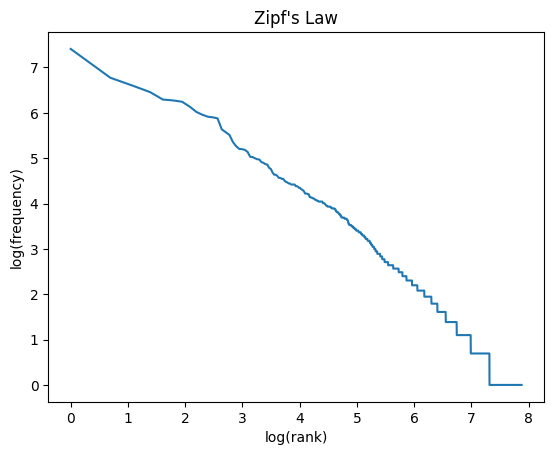

In [33]:
# now the line plot
# visualize
sns.lineplot(x=log_ranks,y=log_freq)
plt.xlabel("log(rank)")
plt.ylabel("log(frequency)")
plt.title("Zipf's Law")
plt.show()

In [34]:
# now we will truncate the noisy tail
# creating a boolean mask
log_ranks = np.array(log_ranks)
log_freq = np.array(log_freq)

mask = log_ranks < 5
log_ranks_trimmed = log_ranks[mask]
log_freq_trimmed = log_freq[mask]

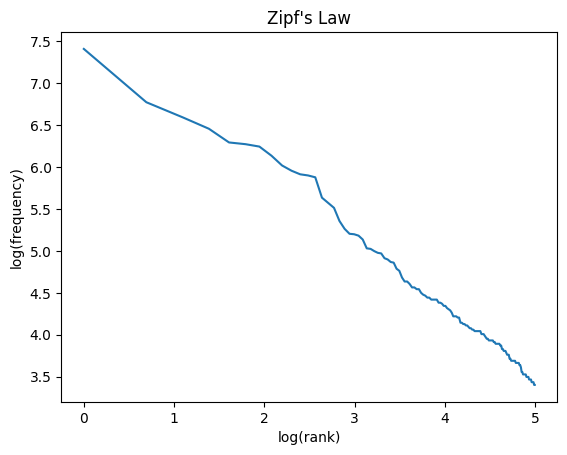

<Figure size 640x480 with 0 Axes>

In [35]:
# now the line plot
# visualize
# after remobing the noisy taill
sns.lineplot(x=log_ranks_trimmed,y=log_freq_trimmed)
plt.xlabel("log(rank)")
plt.ylabel("log(frequency)")
plt.title("Zipf's Law")
plt.show()
plt.savefig("zipfs_law.png")

In [36]:
# importing scipy library
# to calculate the slope
# the slope of the line is exponent of zipf's law
from scipy import stats

slope, intercept, r_value, p_value, std_err = stats.linregress(log_ranks_trimmed,log_freq_trimmed)
print(f"Slope is : {slope}")
print(f"R-squared: {r_value**2}")

Slope is : -0.8503283101415031
R-squared: 0.9904417014870084


In [37]:
# now next part is for Heap's law
# storing n values and v values
# to check how v grows with increse in n

def get_heaps_data(tokens):

  n_values = []
  v_values = []

  unique_words = set()
  for i in range(len(tokens)):
    unique_words.add(tokens[i])

    if i%100==0 or i==len(tokens)-1:
      n_values.append(i+1)
      v_values.append(len(unique_words))

  return np.array(n_values), np.array(v_values)

In [38]:
# checking the function
# working or not
n_values, v_values = get_heaps_data(tokens)
print(len(n_values))
print(n_values[:5], v_values[:5])
print(n_values[-5:], v_values[-5:])

269
[  1 101 201 301 401] [  1  68 127 172 203]
[26401 26501 26601 26701 26776] [2595 2605 2612 2626 2635]


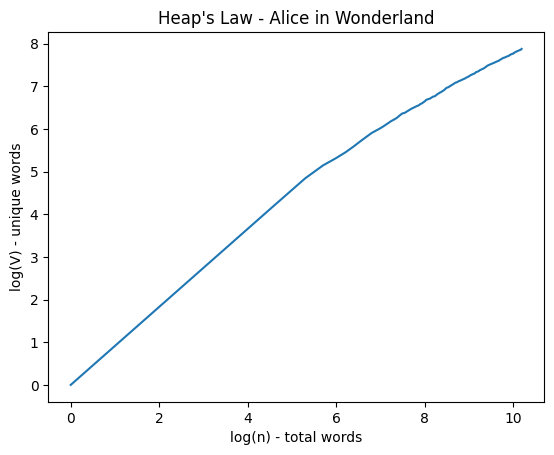

<Figure size 640x480 with 0 Axes>

In [39]:
# now plotting the heaps law curve
# using log-log scale
# will be a stright line
log_n_values = np.log(n_values)
log_v_values = np.log(v_values)

# now plotting a line plot
sns.lineplot(x=log_n_values,y=log_v_values)
plt.title("Heap's Law - Alice in Wonderland")
plt.xlabel("log(n) - total words")
plt.ylabel("log(V) - unique words")
plt.show()
plt.savefig("heaps_law.png")

In [40]:
# now fitting the heap's exponent
slope_heap, intercept_heap, r_value_heap, p_value_heap, std_err_heap = stats.linregress(log_n_values, log_v_values)

print(f"Beta (Heap's exponent): {slope_heap}")
print(f"R-squared: {r_value_heap**2}")

Beta (Heap's exponent): 0.6438878812894996
R-squared: 0.9783116987611727


## Findings

Tested Zipf's and Heap's Laws on *Alice's Adventures in Wonderland* (Project Gutenberg).

**Zipf's Law:** exponent s ≈ 0.85, R² ≈ 0.99. Close to the theoretical value of 1. Tail showed a staircase pattern due to hapax legomena (words occurring once); trimming to top ranks gave a cleaner fit.

**Heap's Law:** exponent β ≈ 0.64, R² ≈ 0.98. Slightly higher than the typical 0.4 to 0.6 range, likely due to the book's short length and inventive vocabulary.

**Takeaway:** Both laws hold reasonably well, with strong R² values, though exact exponents deviate somewhat from textbook norms, expected for a short, single genre text.